In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
x_data = pd.read_csv("Xarray_D1638_11-04_13:49.029886.csv", sep=' ', header= None)
x_data.columns= ["x_profile", "x"]

y_data = pd.read_csv("Yarray_D1638_11-04_13:49.029886.csv", sep=' ', header= None)
y_data.columns= ["y_profile", "y"]

In [4]:
x_error = np.sqrt(np.absolute(x_data["x_profile"]))
y_error = np.sqrt(np.absolute(y_data["y_profile"]))

    - Randomly sample a gaussian from the ys
    - do the same calculation of mean and std
    - repeat 1000+ times
    - now you should have a distribution of means and a distribution of stds (both should be normal). get mean and std of these TWO also using the same method
    - now you have avg_mean +/-sig_mean and avg_std+/-sig_std 

In [5]:
i = 0
iter_num = 50000
xmc_data = [0 for i in range(0,iter_num)]

while(i<iter_num):
    xmc_data[i] = np.random.normal(x_data["x_profile"], x_error)
    i = i + 1

for i in range (0, iter_num):
    plt.plot(x_data["x"], xmc_data[i])
#plt.xlim(250,270)
#plt.ylim(4000,10000)

plt.xlabel("Pixel")
plt.ylabel("Counts")

#plt.savefig("MC_zoomedin", dpi = 300)
plt.savefig("MC_sim", dpi = 300)

plt.show()

In [15]:
def findMean(xx, prof):
    avg_x = []
    norm = []

    avg_x = np.sum(np.multiply(xx, prof**2))
    norm = np.sum(prof**2)

    avg = avg_x/norm
    return avg

def findSTD(xx, prof, avg):
    prof = prof[int(avg-100):int(avg+100)]
    xx = xx[int(avg-100):int(avg+100)]

    avg_x = 0
    avg_x2 = 0
    norm = 0

    avg_x = np.sum(np.multiply(xx, prof**2))
    avg_x2 = np.sum(np.multiply(xx**2, prof**2))
    norm = np.sum(prof**2)
    
    avg = avg_x/norm
    std = np.sqrt(avg_x2/norm - avg**2)
    return std

In [7]:
xmc_mean = [0 for i in range(0,iter_num)]
xmc_std = [0 for i in range(0,iter_num)]

for k in range(0, iter_num):
    xmc_mean[k] = findMean(x_data["x"].values, xmc_data[k])
    xmc_std[k] = findSTD(x_data["x"].values, xmc_data[k], xmc_mean[k])

xmc_mean = np.array(xmc_mean)
xmc_std = np.array(xmc_std)

In [8]:
len(xmc_mean), len(xmc_std)

(50000, 50000)

* Now I have a distribution of means (xmc_mean) and a distribution of stds (xmc_std) (both should be normal). 
* Get mean and std of these two distributions now also using the same method (findMean and findSTD fns)

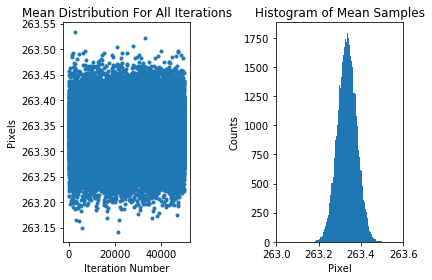

In [161]:
fig, axs = plt.subplots(nrows=1, ncols=2)
ax = axs[0]
ax1= axs[1]

ax.plot(xmc_mean, marker='.', linewidth=0)
ax1.hist(xmc_mean, bins=100)
ax1.xaxis.set_ticks(np.arange(263, 263.7, 0.2))


ax1.set_xlabel("Pixel")
ax1.set_ylabel("Counts")
ax1.set_title("Histogram of Mean Samples")
ax.set_ylabel("Pixels")
ax.set_xlabel("Iteration Number")
ax.set_title("Mean Distribution For All Iterations")

plt.tight_layout()
plt.savefig("x_mean_hist", dpi = 300)

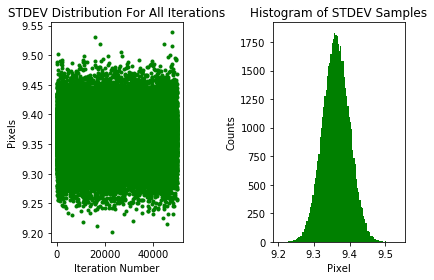

In [163]:
fig, axs = plt.subplots(nrows=1, ncols=2)
ax = axs[0]
ax1= axs[1]

ax.plot(xmc_std, marker='.', linewidth=0, color='g')
ax1.hist(xmc_std, bins=100, color='g')
#ax1.xaxis.set_ticks(np.arange(263, 263.7, 0.2))


ax1.set_xlabel("Pixel")
ax1.set_ylabel("Counts")
ax1.set_title("Histogram of STDEV Samples")
ax.set_ylabel("Pixels")
ax.set_xlabel("Iteration Number")
ax.set_title("STDEV Distribution For All Iterations")

plt.tight_layout()
plt.savefig("x_std_hist", dpi = 300)

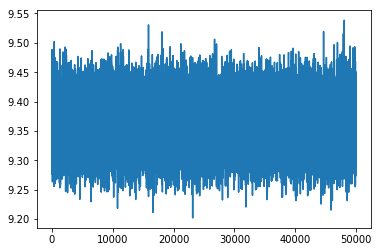

In [10]:
plt.plot(xmc_std)
plt.show()

In [11]:

avg_mean = np.mean(xmc_mean)
std_mean = np.std(xmc_mean)

avg_std = np.mean(xmc_std)
std_std = np.std(xmc_std)

print(avg_mean, std_mean, avg_std, std_std)

263.33466242039884 0.04500873052640908 9.362325298048999 0.03768465219865106


P.S. 5 mm is 41 pixels

# Results from all images

In [25]:
stats = pd.read_csv("data_mean_stdev_pix.txt", sep=' ', header= None)
stats.columns= ["name", "x_mean", "x_mean_std", "x_std_mean", "x_std_std", "y_mean", "y_mean_std", "y_std_mean", "y_std_std"]

In [24]:
old_stats = pd.read_csv("../FP2_err_noOffset/data_mean_stdev_pix.txt", sep=' ', header= None)
old_stats.columns= ["name", "x_mean", "x_mean_std", "x_std_mean", "x_std_std", "y_mean", "y_mean_std", "y_std_mean", "y_std_std"]

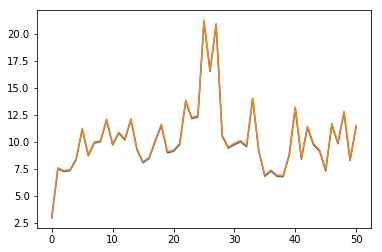

In [36]:
sys_err = old_stats["y_mean"]-stats["y_mean"]
total_err = sys_err + stats["y_mean_std"]

sys_err_std = old_stats["y_std_mean"]-stats["y_std_mean"]
total_err_std = sys_err_std + stats["y_std_std"]

plt.plot(sys_err)
plt.plot(total_err)

In [7]:
x_pics =  np.arange(1,52)

Text(0.5, 1.0, 'Mean')

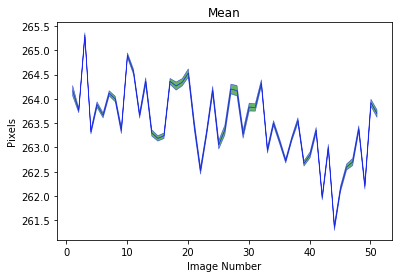

In [10]:
#plt.figure(figsize=(12,8))
plt.fill_between(x_pics, stats['x_mean'],stats['x_mean']+stats["x_mean_std"], alpha=0.6, edgecolor='b', facecolor='g', linewidth=0.6, antialiased=True)           
plt.fill_between(x_pics, stats['x_mean'],stats['x_mean']-stats["x_mean_std"], alpha=0.6, edgecolor='b', facecolor='g', linewidth=0.6, antialiased=True)

plt.xlabel("Image Number")
plt.ylabel("Pixels")
plt.title("Mean")

#plt.savefig("mean_images", dpi = 300)

Text(0.5, 1.0, 'STDEV')

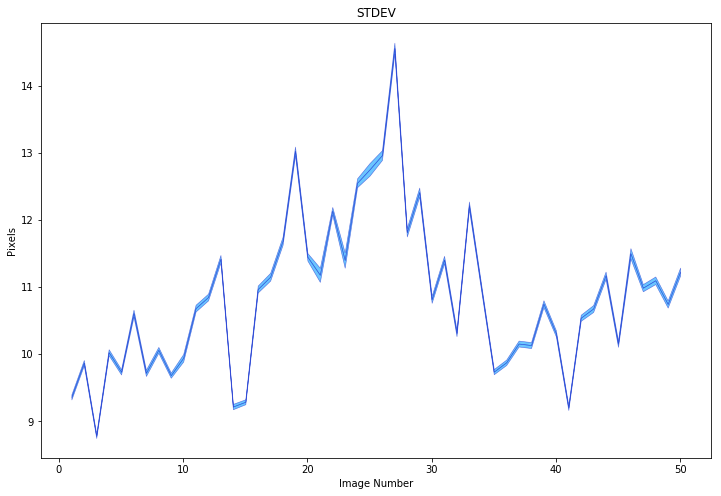

In [111]:
plt.figure(figsize=(12,8))
plt.fill_between(x_pics, stats['x_std_mean'],stats['x_std_mean']+stats["x_std_std"], alpha=0.6, edgecolor='#1B2ACC', facecolor='#089FFF', linewidth=0.6, antialiased=True)           
plt.fill_between(x_pics, stats['x_std_mean'],stats['x_std_mean']-stats["x_std_std"], alpha=0.6, edgecolor='#1B2ACC', facecolor='#089FFF', linewidth=0.6, antialiased=True)  

plt.xlabel("Image Number")
plt.ylabel("Pixels")
plt.title("STDEV")

Text(0, 0.5, 'Pixels')

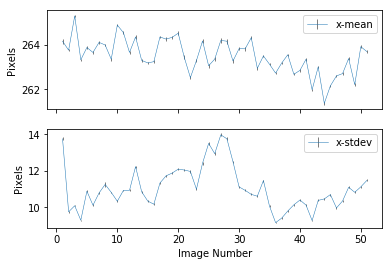

In [11]:

fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True)
ax = axs[0]
ax1= axs[1]

ax.errorbar(x_pics, stats['x_mean'], yerr =stats["x_mean_std"], linewidth=0.5, ecolor='black', capthick=2, label="x-mean")
ax.legend()

ax1.errorbar(x_pics, stats['x_std_mean'], yerr = stats["x_std_std"],linewidth=0.5, ecolor='black', capthick=2, label='x-stdev')
ax1.legend()

ax1.set_xlabel("Image Number")
ax1.set_ylabel("Pixels")
ax.set_ylabel("Pixels")

#plt.savefig("x_mean_stdev_allim", dpi = 300)

Text(0, 0.5, 'Pixels')

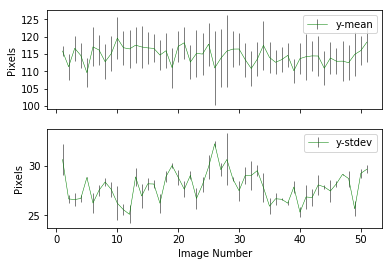

In [37]:

fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True)
ax = axs[0]
ax1= axs[1]

ax.errorbar(x_pics, stats['y_mean'], yerr =total_err/2, linewidth=0.5, ecolor='black', color = 'g', capthick=2, label="y-mean")
ax.legend()
ax.locator_params(nbins=6)

ax1.errorbar(x_pics, stats['y_std_mean'], yerr = total_err_std/2,linewidth=0.5, ecolor='black', color = 'g', capthick=2, label='y-stdev')
ax1.legend()

ax1.set_xlabel("Image Number")
ax1.set_ylabel("Pixels")
ax.set_ylabel("Pixels")

#plt.savefig("y_mean_stdev_allim_wErr", dpi = 300)

In [13]:
print("Max x: ",np.max(stats['x_mean']), "Min x: ", np.min(stats['x_mean']))
print("Max y: ",np.max(stats['y_mean']), "Min x: ", np.min(stats['y_mean']))

Max x:  265.3237982606568 Min x:  261.36374171868226
Max y:  119.5743674290382 Min x:  109.58845070038693


In [19]:
print("X range in  mm ", (265.18322323395694 -261.36374171868226)*5/41)
print("Y range in  mm ", (119.5743674290382 -109.58845070038693)*5/41)

X range in  mm  0.4657904286920334
Y range in  mm  1.2177947230062531


In [20]:
print("Max x: ",np.max(stats['x_std_mean']), "Min x: ", np.min(stats['x_std_mean']))
print("Max y: ",np.max(stats['y_std_mean']), "Min x: ", np.min(stats['y_std_mean']))

Max x:  13.966294736206946 Min x:  9.150898305544718
Max y:  32.26551715025933 Min x:  25.1099654001428


In [21]:
print("X size in  mm ", (13.966294736206946*2)*5/41)
print("Y size in  mm ", (32.26551715025933*2)*5/41)

X size in  mm  3.4064133502943768
Y size in  mm  7.869638329331543


In [22]:
print("fraction of x spot size in movement: ", 0.46/3.4*100, "%")

fraction of x spot size in movement:  13.529411764705884 %


In [23]:
print("fraction of y spot size in movement: ", 1.21/7.87*100, "%")

fraction of y spot size in movement:  15.374841168996186 %
